# 🤖 AI Expert Tasks — YoungDev Interns
**01 Month Remote Internship**

---

## Tasks Overview
- **Task 1:** Advanced Model with Hyperparameter Tuning (GridSearchCV / RandomizedSearchCV)
- **Task 2:** Deep Learning Model — CNN for Image Classification (Keras)
- **Task 3:** Deploy a Machine Learning Model with Flask REST API


---
## Task 1 — Advanced Model with Hyperparameter Tuning
**Goal:** Use GridSearchCV and RandomizedSearchCV to optimise Random Forest and Gradient Boosting.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, RocCurveDisplay

# Load & split
bc   = load_breast_cancer(as_frame=True)
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (455, 30)  |  Test: (114, 30)


In [5]:
# Baseline
rf_base = RandomForestClassifier(random_state=42).fit(X_tr_sc, y_train)
gb_base = GradientBoostingClassifier(random_state=42).fit(X_tr_sc, y_train)

print("=== Baseline Scores ===")
print(f"Random Forest     : {accuracy_score(y_test, rf_base.predict(X_te_sc)):.4f}")
print(f"Gradient Boosting : {accuracy_score(y_test, gb_base.predict(X_te_sc)):.4f}")


=== Baseline Scores ===
Random Forest     : 0.9561
Gradient Boosting : 0.9561


In [7]:
# GridSearchCV on Random Forest
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features'    : ['sqrt', 'log2'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_tr_sc, y_train)

print("=== GridSearchCV - Random Forest ===")
print(f"Best ROC-AUC (CV) : {rf_grid.best_score_:.4f}")
print(f"Best params       : {rf_grid.best_params_}")


=== GridSearchCV - Random Forest ===
Best ROC-AUC (CV) : 0.9910
Best params       : {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}


In [8]:
# RandomizedSearchCV on Gradient Boosting
from scipy.stats import randint, uniform

gb_param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(2, 8),
    'learning_rate'   : uniform(0.01, 0.29),
    'subsample'       : uniform(0.6, 0.4),
    'min_samples_split': randint(2, 10),
}
gb_rand = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist, n_iter=40, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=-1)
gb_rand.fit(X_tr_sc, y_train)

print("=== RandomizedSearchCV - Gradient Boosting ===")
print(f"Best ROC-AUC (CV) : {gb_rand.best_score_:.4f}")
print(f"Best params       : {gb_rand.best_params_}")


=== RandomizedSearchCV - Gradient Boosting ===
Best ROC-AUC (CV) : 0.9945
Best params       : {'learning_rate': 0.2737029166028468, 'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 459, 'subsample': 0.902144564127061}


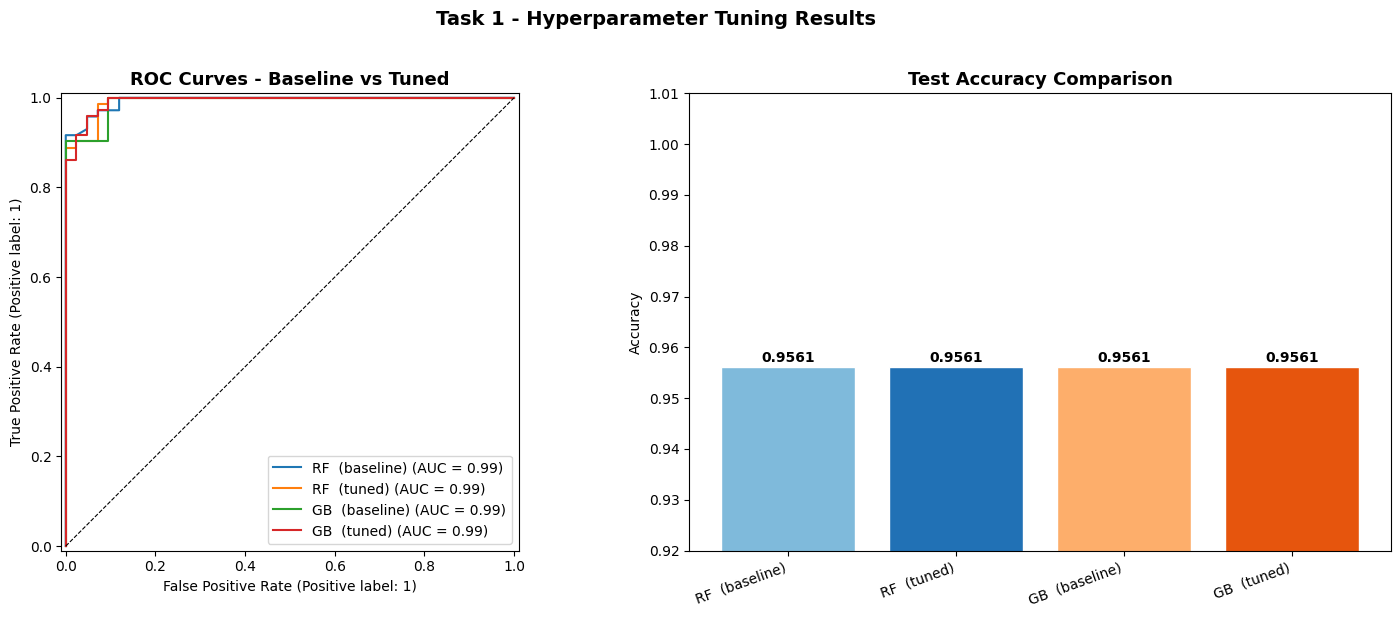

Task 1 complete!


In [12]:
# Compare all four models
models = {
    'RF  (baseline)' : rf_base,
    'RF  (tuned)'    : rf_grid.best_estimator_,
    'GB  (baseline)' : gb_base,
    'GB  (tuned)'    : gb_rand.best_estimator_,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, clf in models.items():
    RocCurveDisplay.from_estimator(clf, X_te_sc, y_test, ax=axes[0], name=name)
axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set_title('ROC Curves - Baseline vs Tuned', fontsize=13, fontweight='bold')

acc_scores = {n: accuracy_score(y_test, m.predict(X_te_sc)) for n, m in models.items()}
colors = ['#7fbadb','#2171b5','#fdae6b','#e6550d']
axes[1].bar(acc_scores.keys(), acc_scores.values(), color=colors, edgecolor='white')
axes[1].set_ylim(0.92, 1.01)
axes[1].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticklabels(acc_scores.keys(), rotation=20, ha='right')
for i, (k, v) in enumerate(acc_scores.items()):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Task 1 - Hyperparameter Tuning Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('/tmp/task1_expert_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print("Task 1 complete!")


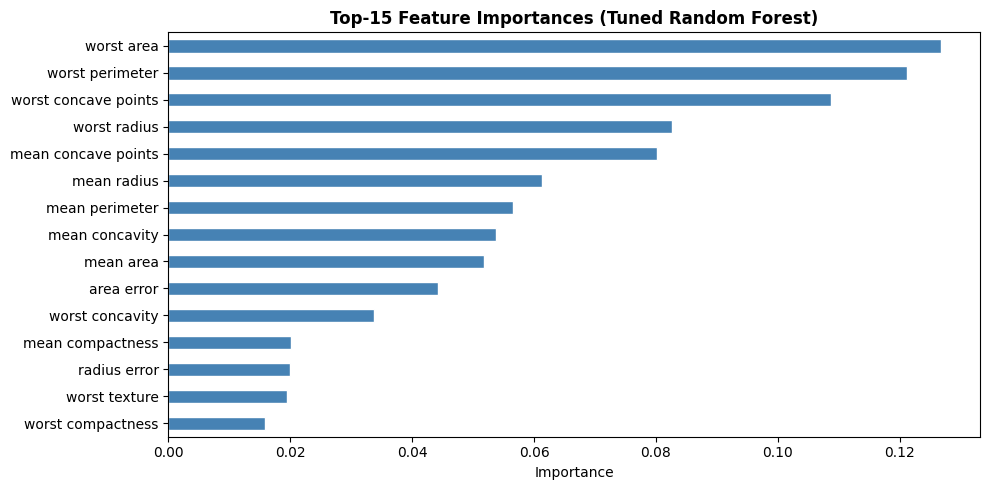

In [13]:
# Feature importance from best RF
best_rf     = rf_grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top15       = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 5))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top-15 Feature Importances (Tuned Random Forest)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()


---
## Task 2 — Deep Learning: CNN for Image Classification
**Goal:** Build a CNN with Keras for MNIST, using Dropout and Batch Normalization.


In [3]:
%pip install tensorflow-cpu

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.66.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
tensorflow-metadata 1.16.1 requires protobuf<6.0.0dev,>=4.25.2; python_version >= "3.11", but you have protobuf 7.35.1 which is incompatible.
urduhack 1.0.3 requires Click~=7.1, but you have click 8.1.7 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached grpcio-1.81.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.1-cp312-cp312-win_amd64.whl.metadata (32 kB)
Usin

In [7]:
%pip install protobuf==6.31.1

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.66.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
tensorflow-metadata 1.16.1 requires protobuf<6.0.0dev,>=4.25.2; python_version >= "3.11", but you have protobuf 6.31.1 which is incompatible.
urduhack 1.0.3 requires Click~=7.1, but you have click 8.1.7 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Load MNIST
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()
X_train_cnn = X_train_raw[..., np.newaxis].astype('float32') / 255.0
X_test_cnn  = X_test_raw[...,  np.newaxis].astype('float32') / 255.0
y_train_ohe = keras.utils.to_categorical(y_train_raw, 10)
y_test_ohe  = keras.utils.to_categorical(y_test_raw,  10)

print(f"Train: {X_train_cnn.shape}  |  Test: {X_test_cnn.shape}")


TensorFlow version: 2.21.0
Train: (60000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


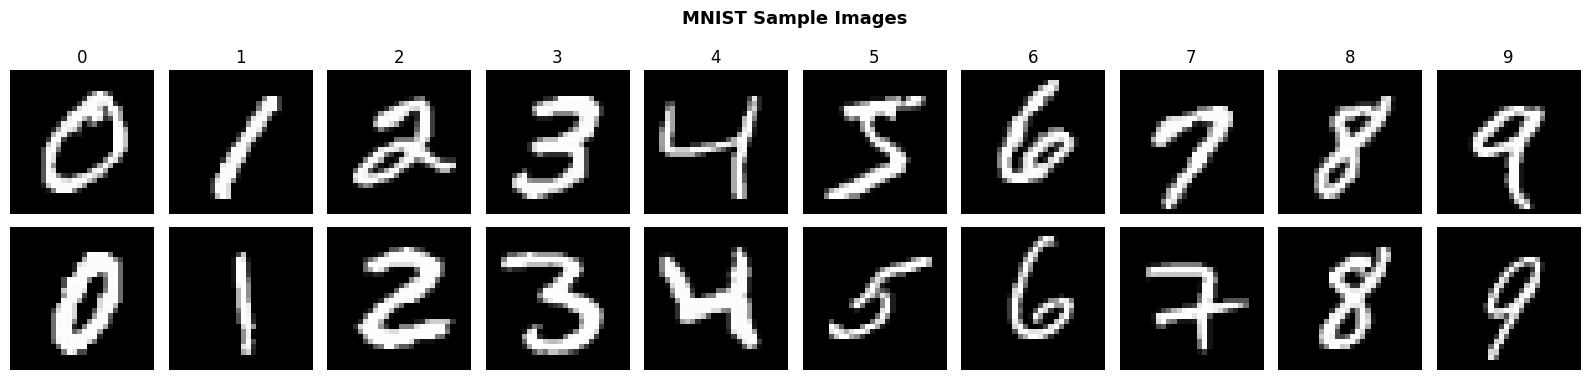

In [4]:
# Sample images
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    for row, pick in enumerate([0, 2]):
        idx = np.where(y_train_raw == digit)[0][pick]
        axes[row, digit].imshow(X_train_raw[idx], cmap='gray')
        if row == 0: axes[row, digit].set_title(str(digit))
        axes[row, digit].axis('off')
plt.suptitle('MNIST Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [5]:
# Build CNN
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='CNN_MNIST')
    return model

cnn = build_cnn()
cnn.summary()


Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
# Compile & train
cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                   restore_best_weights=True, verbose=1),
]

history = cnn.fit(
    X_train_cnn, y_train_ohe,
    epochs=20, batch_size=128, validation_split=0.1,
    callbacks=callbacks, verbose=1)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 173s 398ms/step - accuracy: 0.9435 - loss: 0.1845 - val_accuracy: 0.8767 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 174s 413ms/step - accuracy: 0.9811 - loss: 0.0643 - val_accuracy: 0.9908 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 203s 416ms/step - accuracy: 0.9850 - loss: 0.0484 - val_accuracy: 0.9898 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 183s 433ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.9873 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 167s 395ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9927 - val_loss: 0.0260 - learning_rate: 5.0000e-04
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 177s 420ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9942 - val_loss: 0.0216 - learning_rate: 5.0000e-04
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 166s 393ms/step 

Test Loss     : 0.0117
Test Accuracy : 0.9963 (99.63%)


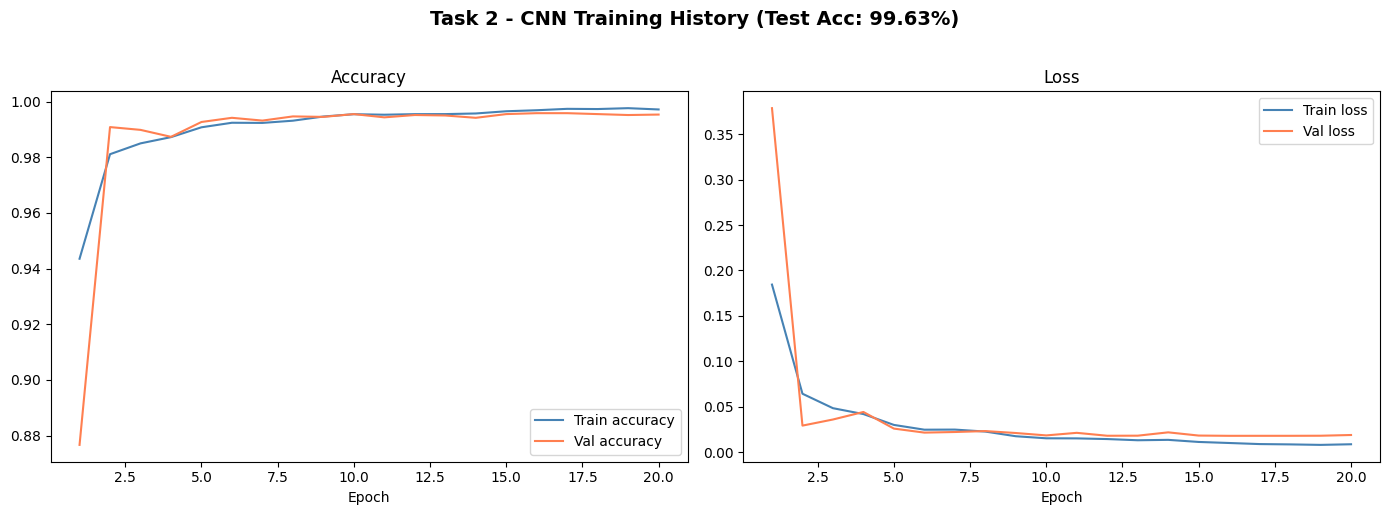

Task 2 complete!


In [8]:
# Evaluate
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history.history['accuracy']) + 1)
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(ep, history.history[metric],         label=f'Train {metric}', color='steelblue')
    ax.plot(ep, history.history[f'val_{metric}'],label=f'Val {metric}',   color='coral')
    ax.set_title(metric.capitalize(), fontsize=12); ax.set_xlabel('Epoch'); ax.legend()

plt.suptitle(f'Task 2 - CNN Training History (Test Acc: {test_acc:.2%})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('/tmp/task2_expert_cnn.png', dpi=120, bbox_inches='tight')
plt.show()
print("Task 2 complete!")


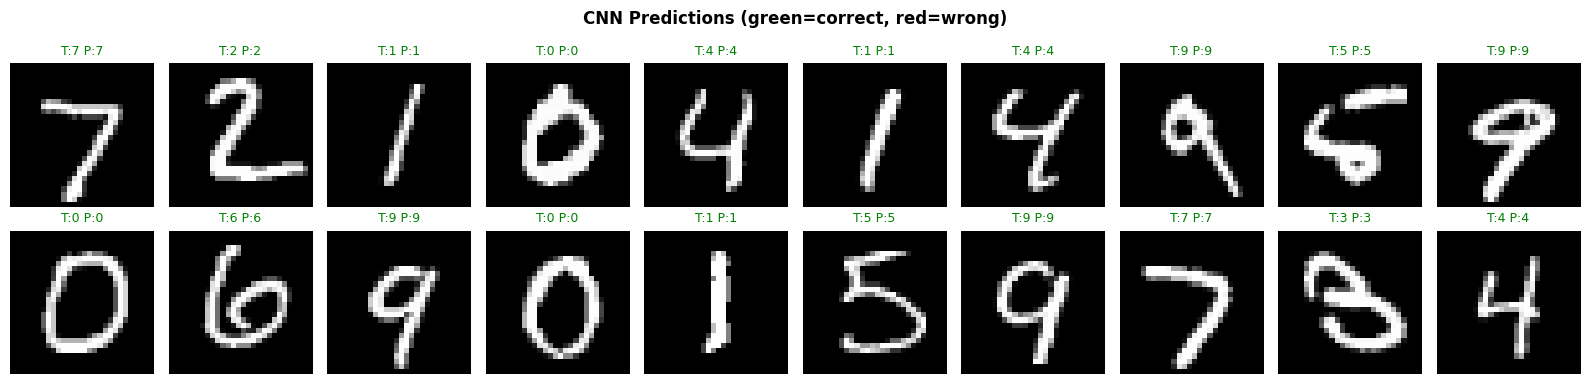

In [9]:
# Predictions on 20 test images
y_pred_cls = np.argmax(cnn.predict(X_test_cnn[:20], verbose=0), axis=1)
fig, axes  = plt.subplots(2, 10, figsize=(16, 4))
for i in range(20):
    ax = axes[i//10, i%10]
    ax.imshow(X_test_raw[i], cmap='gray')
    true = y_test_raw[i]; pred = y_pred_cls[i]
    ax.set_title(f'T:{true} P:{pred}',
                 color='green' if true==pred else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle('CNN Predictions (green=correct, red=wrong)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Task 3 — Deploy a Machine Learning Model with Flask
**Goal:** Create a Flask REST API for a trained ML model with health-check, single, and batch prediction endpoints.


In [10]:
import pickle, os, json
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Train & serialise
bc = load_breast_cancer(as_frame=True)
X, y = bc.data, bc.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
clf    = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
clf.fit(scaler.fit_transform(X_tr), y_tr)

print(f"Model accuracy: {accuracy_score(y_te, clf.predict(scaler.transform(X_te))):.4f}")

os.makedirs('/tmp/flask_model', exist_ok=True)
with open('/tmp/flask_model/model.pkl',  'wb') as f: pickle.dump(clf,    f)
with open('/tmp/flask_model/scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('/tmp/flask_model/features.json', 'w') as f:
    json.dump({'features': bc.feature_names.tolist(),
               'target_names': bc.target_names.tolist()}, f)
print("Model + scaler saved.")


Model accuracy: 0.9561
Model + scaler saved.


In [11]:
# Write Flask app to disk
app_code = r'''
import pickle, json, os
import numpy as np
from flask import Flask, request, jsonify

BASE = "/tmp/flask_model"
with open(f"{BASE}/model.pkl",  "rb") as f: model  = pickle.load(f)
with open(f"{BASE}/scaler.pkl", "rb") as f: scaler = pickle.load(f)
with open(f"{BASE}/features.json")    as f: meta   = json.load(f)

FEATURE_NAMES = meta["features"]
TARGET_NAMES  = meta["target_names"]
N_FEATURES    = len(FEATURE_NAMES)

app = Flask(__name__)

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "GradientBoostingClassifier",
                    "n_features": N_FEATURES})

@app.route("/features", methods=["GET"])
def features():
    return jsonify({"features": FEATURE_NAMES, "classes": TARGET_NAMES})

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(force=True)
    if "features" not in data:
        return jsonify({"error": "Missing key: features"}), 400
    vec = np.array(data["features"]).reshape(1, -1)
    if vec.shape[1] != N_FEATURES:
        return jsonify({"error": f"Expected {N_FEATURES} features"}), 400
    scaled   = scaler.transform(vec)
    pred_cls = int(model.predict(scaled)[0])
    probs    = model.predict_proba(scaled)[0].tolist()
    return jsonify({"prediction": pred_cls, "label": TARGET_NAMES[pred_cls],
                    "probabilities": {c: round(p, 4) for c, p in zip(TARGET_NAMES, probs)}})

@app.route("/predict_batch", methods=["POST"])
def predict_batch():
    data = request.get_json(force=True)
    if "samples" not in data:
        return jsonify({"error": "Missing key: samples"}), 400
    mat    = np.array(data["samples"])
    scaled = scaler.transform(mat)
    preds  = model.predict(scaled).tolist()
    probs  = model.predict_proba(scaled).tolist()
    return jsonify({"predictions": [
        {"prediction": p, "label": TARGET_NAMES[p],
         "probabilities": {c: round(pr, 4) for c, pr in zip(TARGET_NAMES, prob)}}
        for p, prob in zip(preds, probs)]})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5050, debug=False)
'''

with open('/tmp/flask_model/app.py', 'w') as f:
    f.write(app_code)

print("Flask app written to /tmp/flask_model/app.py")
print(app_code)


Flask app written to /tmp/flask_model/app.py

import pickle, json, os
import numpy as np
from flask import Flask, request, jsonify

BASE = "/tmp/flask_model"
with open(f"{BASE}/model.pkl",  "rb") as f: model  = pickle.load(f)
with open(f"{BASE}/scaler.pkl", "rb") as f: scaler = pickle.load(f)
with open(f"{BASE}/features.json")    as f: meta   = json.load(f)

FEATURE_NAMES = meta["features"]
TARGET_NAMES  = meta["target_names"]
N_FEATURES    = len(FEATURE_NAMES)

app = Flask(__name__)

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "GradientBoostingClassifier",
                    "n_features": N_FEATURES})

@app.route("/features", methods=["GET"])
def features():
    return jsonify({"features": FEATURE_NAMES, "classes": TARGET_NAMES})

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(force=True)
    if "features" not in data:
        return jsonify({"error": "Missing key: features"}), 400
    vec = np

In [ ]:
# Launch Flask server & run tests
import subprocess, time, requests

server = subprocess.Popen(['python3', '/tmp/flask_model/app.py'],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)

BASE_URL = 'http://localhost:5050'

print("=== GET /health ===")
r = requests.get(f'{BASE_URL}/health')
print(json.dumps(r.json(), indent=2))

print("\n=== POST /predict (single sample) ===")
sample = X_te.iloc[0].tolist()
r = requests.post(f'{BASE_URL}/predict', json={'features': sample})
resp = r.json()
print(json.dumps(resp, indent=2))
print(f"True label: {bc.target_names[y_te.iloc[0]]}")

print("\n=== POST /predict_batch (5 samples) ===")
r = requests.post(f'{BASE_URL}/predict_batch',
                  json={'samples': X_te.iloc[:5].values.tolist()})
for i, result in enumerate(r.json()['predictions']):
    true = bc.target_names[y_te.iloc[i]]
    pred = result['label']
    ok   = 'OK' if true == pred else 'WRONG'
    print(f"  Sample {i+1}: True={true:10s}  Pred={pred:10s}  [{ok}]")

server.terminate()
print("\nFlask server stopped.")
print("Task 3 complete!")


In [ ]:
# Deployment architecture summary
diagram = '''
+===============================================================+
|               DEPLOYMENT ARCHITECTURE                         |
+===============================================================+
|                                                               |
|   Client  (browser / mobile app / curl)                       |
|        |                                                      |
|        |  HTTP POST /predict  { features: [...] }             |
|        v                                                      |
|   +----------------------------------------------------------+|
|   |         Flask REST API  (port 5050)                      ||
|   |   Endpoints:                                             ||
|   |     GET  /health           liveness probe                ||
|   |     GET  /features         feature names + classes       ||
|   |     POST /predict          single-sample inference       ||
|   |     POST /predict_batch    batch inference               ||
|   +------------------------------+---------------------------+|
|                                  |                            |
|                                  v                            |
|   +----------------------------------------------------------+|
|   |  Inference Pipeline                                      ||
|   |   raw input -> StandardScaler -> GBClassifier            ||
|   |             -> prediction + class probabilities          ||
|   +----------------------------------------------------------+|
|                                                               |
|   Cloud deployment options:                                   |
|     * AWS  : Elastic Beanstalk / Lambda + API Gateway         |
|     * Azure: App Service / Container Instances                |
|     * GCP  : Cloud Run / App Engine                           |
|     * Any  : Docker + Kubernetes                              |
+===============================================================+
'''
print(diagram)
